In [1]:
# %% [markdown]
# # CMAPSS FD001 – LSTM with Keras
# 
# - Loads CMAPSS via step1_ml_pipeline
# - Builds sliding windows per engine
# - Trains an LSTM for RUL regression
# - Reports MAE / RMSE / R²

# %%
!pip install tensorflow --quiet

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from step1_ml_pipeline import load_cmapss_data, data_processing



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# %% 
# Load and standardize CMAPSS using your existing pipeline
dataname = "FD001"

train_df_raw, test_df_raw = load_cmapss_data(dataname)
train_std, test_std, scaler = data_processing(train_df_raw, test_df_raw)

print(train_std.head())
print(test_std.head())

print("Columns:", list(train_std.columns))


   engine_id  cycle  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0          1      1       0.0 -1.214815 -0.049261 -0.610086       0.0   
1          1      2       0.0 -0.725926  0.211823 -0.401804       0.0   
2          1      3       0.0 -0.429630 -0.259852 -0.314883       0.0   
3          1      4       0.0 -0.429630 -0.900246 -0.505945       0.0   
4          1      5       0.0 -0.400000 -0.892857 -0.149241       0.0   

   sensor_6  sensor_7  sensor_8  ...  sensor_13  sensor_14  sensor_15  \
0       0.0  0.766667 -0.333333  ...       -0.7  -0.127448  -0.382643   
1       0.0  0.258333 -0.555556  ...       -0.2  -0.600730  -0.140039   
2       0.0  0.683333 -0.111111  ...       -0.6  -0.485231  -0.416174   
3       0.0  0.841667  0.222222  ...       -0.1  -0.445403  -1.394477   
4       0.0  0.466667 -0.333333  ...       -0.5  -0.447395  -0.187377   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  RUL  
0        0.0       -0.5        0.0        0.0  

In [10]:
# %%
# Columns to use as features (drop id / target)
exclude = ["engine_id", "cycle", "RUL"]
feature_cols = [c for c in train_std.columns if c not in exclude]
n_features = len(feature_cols)
print("Num features:", n_features)

# Split engines: some engines for training, some for validation
val_frac = 0.15
rng = np.random.default_rng(seed=42)

eng_ids = train_std["engine_id"].unique()
rng.shuffle(eng_ids)

cut = int((1.0 - val_frac) * len(eng_ids))
val_ids = set(eng_ids[cut:])

mask_val = train_std["engine_id"].isin(val_ids)

train_df = train_std[~mask_val].copy()
val_df   = train_std[mask_val].copy()
test_df  = test_std.copy()

print(f"# train engines: {train_df['engine_id'].nunique()}")
print(f"#  val  engines: {val_df['engine_id'].nunique()}")
print(f"# test engines:  {test_df['engine_id'].nunique()}")


Num features: 21
# train engines: 85
#  val  engines: 15
# test engines:  100


In [ ]:
# %% 
def make_windows(df, feature_cols, window_size):
    """
    df: DataFrame with engine_id, cycle, RUL, and sensor features
    returns:
      X: (N, window_size, n_features)
      y: (N,)
    """
    X_list = []
    y_list = []

    for eng_id, eng_df in df.groupby("engine_id"):
        eng_df = eng_df.sort_values("cycle")
        feats = eng_df[feature_cols].to_numpy()
        rul   = eng_df["RUL"].to_numpy()

        if len(eng_df) < window_size:
            continue  # skip very short engines (rare)

        for start in range(0, len(eng_df) - window_size + 1):
            end = start + window_size
            X_seq = feats[start:end, :]                 # (window_size, n_features)
            y_val = rul[end - 1]                        # RUL at last time step
            X_list.append(X_seq)
            y_list.append(y_val)

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=float)
    return X, y

window_size = 120
print("Making sliding windows with window_size =", window_size)

X_tr, y_tr = make_windows(train_df, feature_cols, window_size)
X_val, y_val = make_windows(val_df, feature_cols, window_size)
X_te, y_te = make_windows(test_df, feature_cols, window_size)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_te:", X_te.shape, "y_te:", y_te.shape)


Making sliding windows with window_size = 130
X_tr: (6603, 130, 21) y_tr: (6603,)
X_val: (1129, 130, 21) y_val: (1129,)
X_te: (2250, 130, 21) y_te: (2250,)


In [ ]:
# %%  LSTM + simple temporal attention
# import tensorflow as tf
# from tensorflow import keras

# input_shape = (window_size, n_features)
# inputs = keras.Input(shape=input_shape)

# # 1) Stacked LSTM that keeps the full sequence
# x = keras.layers.LSTM(64, return_sequences=True)(inputs)
# x = keras.layers.LSTM(32, return_sequences=True)(x)   # keep all time steps

# # 2) Attention over time dimension
# # x shape: (batch, T, H)

# score = keras.layers.Dense(1, activation="tanh")(x)    # (batch, T, 1)
# weights = keras.layers.Softmax(axis=1)(score)          # attention weights over T

# # weighted sum of hidden states
# weighted = keras.layers.Multiply()([x, weights])       # (batch, T, H)
# context = keras.layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(weighted)  # (batch, H)

# # 3) Dense + output
# h = keras.layers.Dense(64, activation="relu")(context)
# outputs = keras.layers.Dense(1)(h)

# model = keras.Model(inputs=inputs, outputs=outputs)
# model.summary()



Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 130, 21)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_22 (LSTM)      │ (None, 130, 64)   │     22,016 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_23 (LSTM)      │ (None, 130, 32)   │     12,416 │ lstm_22[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 130, 1)    │         33 │ lstm_23[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 130, 1)    │          0 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 130, 32)   │          0 │ lstm_23[0][0],    │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      2,112 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1)         │         65 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 36,642 (143.13 KB)

 Trainable params: 36,642 (143.13 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# %%  LSTM + simple temporal attention (with tuning options)
import tensorflow as tf
from tensorflow import keras

input_shape = (window_size, n_features)
inputs = keras.Input(shape=input_shape)

# =========================
# 1) LSTM STACK (capacity)
# =========================
# 🔧 TUNE: number of units, number of layers, dropout

# Option A: your current setup (good baseline)
x = keras.layers.LSTM(64, return_sequences=True)(inputs)
x = keras.layers.LSTM(32, return_sequences=True)(x)

# Option B: smaller model (try if you suspect overfitting)
# x = keras.layers.LSTM(32, return_sequences=True)(inputs)
# x = keras.layers.LSTM(16, return_sequences=True)(x)

# Option C: bigger model (only if you have time/compute)
# x = keras.layers.LSTM(128, return_sequences=True)(inputs)
# x = keras.layers.LSTM(64,  return_sequences=True)(x)

# Option D: add dropout for regularization
x = keras.layers.LSTM(64, return_sequences=True)(inputs)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.LSTM(32, return_sequences=True)(x)
x = keras.layers.Dropout(0.2)(x)


# =======================================
# 2) Attention over time dimension (T)
# =======================================
# x shape here: (batch, T, H)

# --- Simple attention (your current version) ---
score = keras.layers.Dense(1, activation="tanh")(x)   # (batch, T, 1)

# --- Tuned attention: add hidden dimension ---
# 🔧 TUNE: attn_dim = 16, 32, 64
attn_dim = 32
score = keras.layers.Dense(attn_dim, activation="tanh")(x)  # (batch, T, attn_dim)
score = keras.layers.Dense(1)(score)                        # (batch, T, 1)

# --- Alternative: linear scores (no activation) ---
# score = keras.layers.Dense(1, activation=None)(x)

weights = keras.layers.Softmax(axis=1)(score)         # attention weights over T (batch, T, 1)

# weighted sum of hidden states
weighted = keras.layers.Multiply()([x, weights])      # (batch, T, H)
context = keras.layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(weighted)  # (batch, H)


# ===========================
# 3) Dense head + output
# ===========================
# 🔧 TUNE: dense units, dropout

h = keras.layers.Dense(64, activation="relu")(context)

# Optional dropout on dense layer (try 0.1–0.3)
# h = keras.layers.Dense(64, activation="relu")(context)
# h = keras.layers.Dropout(0.2)(h)

outputs = keras.layers.Dense(1)(h)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 130, 21)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_28 (LSTM)      │ (None, 130, 64)   │     22,016 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 130, 64)   │          0 │ lstm_28[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_29 (LSTM)      │ (None, 130, 32)   │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 130, 32)   │          0 │ lstm_29[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 130, 32)   │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 130, 1)    │         33 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_2 (Softmax) │ (None, 130, 1)    │          0 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 130, 32)   │          0 │ dropout_1[0][0],  │
│ (Multiply)          │                   │            │ softmax_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 32)        │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      2,112 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │         65 │ dense_31[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,698 (147.26 KB)

 Trainable params: 37,698 (147.26 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# %%  (new cell – after model = keras.Model(...) )
import tensorflow as tf
from tensorflow import keras

def nasa_score_metric(y_true, y_pred):
    # y_true, y_pred shape: (batch, 1)
    d = y_pred - y_true
    s = tf.where(
        d < 0.0,
        tf.exp(-d / 13.0) - 1.0,   # early predictions (pessimistic)
        tf.exp(d / 10.0) - 1.0     # late predictions (over-optimistic)
    )
    # mean per batch, good for logging
    return tf.reduce_mean(s)


In [83]:
# %%  (your compile cell – replace its contents with this)
loss_fn = keras.losses.Huber(delta=20.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        nasa_score_metric      # <- our custom metric
    ]
)


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)


In [84]:
# %%
batch_size = 256
epochs = 80

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)


Epoch 1/80
26/26 - 9s - 333ms/step - MAE: 50.9611 - loss: 839.9448 - nasa_score_metric: 137814.5938 - val_MAE: 44.7791 - val_loss: 722.6307 - val_nasa_score_metric: 10765.4990 - learning_rate: 0.0010
Epoch 2/80
26/26 - 6s - 236ms/step - MAE: 44.7068 - loss: 724.1784 - nasa_score_metric: 77361.3281 - val_MAE: 37.9297 - val_loss: 593.9104 - val_nasa_score_metric: 5580.8257 - learning_rate: 0.0010
Epoch 3/80
26/26 - 6s - 224ms/step - MAE: 38.5262 - loss: 602.6124 - nasa_score_metric: 38065.6602 - val_MAE: 33.4044 - val_loss: 503.1609 - val_nasa_score_metric: 3645.1980 - learning_rate: 0.0010
Epoch 4/80
26/26 - 6s - 212ms/step - MAE: 34.6005 - loss: 522.5504 - nasa_score_metric: 19859.8164 - val_MAE: 30.8719 - val_loss: 450.0618 - val_nasa_score_metric: 1757.0330 - learning_rate: 0.0010
Epoch 5/80
26/26 - 6s - 212ms/step - MAE: 32.3635 - loss: 477.7052 - nasa_score_metric: 11907.3740 - val_MAE: 29.5011 - val_loss: 420.8963 - val_nasa_score_metric: 2484.6406 - learning_rate: 0.0010
Epoch 6/

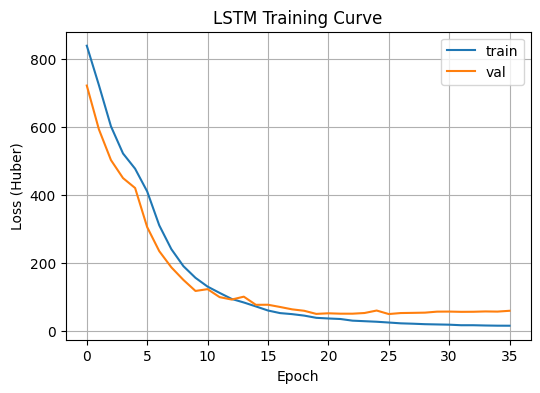

In [85]:
# %%
hist = history.history

plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber)")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(True)
plt.show()


In [86]:
# %%
y_pred = model.predict(X_te).ravel()

mae  = float(np.mean(np.abs(y_te - y_pred)))
rmse = float(np.sqrt(np.mean((y_te - y_pred)**2)))
ss_res = float(np.sum((y_te - y_pred)**2))
ss_tot = float(np.sum((y_te - np.mean(y_te))**2))
r2 = 1.0 - ss_res / ss_tot

def nasa_score_numpy(y_true, y_pred):
    d = y_pred - y_true
    s = np.where(
        d < 0,
        np.exp(-d / 13.0) - 1.0,
        np.exp(d / 10.0) - 1.0
    )
    return float(np.sum(s))

nasa = nasa_score_numpy(y_te, y_pred)

print(f"Test MAE   = {mae:.2f}")
print(f"Test RMSE  = {rmse:.2f}")
print(f"Test R²    = {r2:.3f}")
print(f"NASA score = {nasa:.2f}")


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
Test MAE   = 15.67
Test RMSE  = 22.29
Test R²    = 0.767
NASA score = 41916.16
